Чтение и обработка текста

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path


def read_english_emotion_file(path):
    rows = []

    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            if ";" not in line:
                continue

            text, label = line.rsplit(";", 1)

            text = text.strip()
            label = label.strip()

            if not text or not label:
                continue

            rows.append(
                {
                    "text": text,
                    "label": label,
                }
            )

    return pd.DataFrame(rows)


def find_project_dir():
    current_dir = Path.cwd()

    for path in [current_dir] + list(current_dir.parents):
        if (path / "data" / "english" / "train.txt").exists():
            return path

    raise FileNotFoundError(
        "Не удалось найти корень проекта. "
        "Проверь, что файл data/english/train.txt существует."
    )


PROJECT_DIR = find_project_dir()

train_path = PROJECT_DIR / "data" / "english" / "train.txt"
test_path = PROJECT_DIR / "data" / "english" / "test.txt"

print("PROJECT_DIR:", PROJECT_DIR)
print("train_path:", train_path)
print("test_path:", test_path)
print("train exists:", train_path.exists())
print("test exists:", test_path.exists())

train_df = read_english_emotion_file(train_path)
test_df = read_english_emotion_file(test_path)

print(train_df.head())
print(test_df.head())

PROJECT_DIR: /home/maria/Загрузки/emotion_bot_project
train_path: /home/maria/Загрузки/emotion_bot_project/data/english/train.txt
test_path: /home/maria/Загрузки/emotion_bot_project/data/english/test.txt
train exists: True
test exists: True
                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger
                                                text    label
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate from me because i do...  sadness
3  i left with my bouquet of red and yellow tulip...      joy
4    i was feeling a little vain when i did this one  sadness


In [8]:
from collections import Counter

all_words = []

for text in train_df["text"]:
    words = text.lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

word_counts.most_common(30)

[('i', 25859),
 ('feel', 11183),
 ('and', 9589),
 ('to', 8972),
 ('the', 8370),
 ('a', 6200),
 ('feeling', 5112),
 ('that', 5112),
 ('of', 4990),
 ('my', 4283),
 ('in', 3433),
 ('it', 3127),
 ('like', 2908),
 ('so', 2527),
 ('for', 2431),
 ('im', 2430),
 ('me', 2309),
 ('but', 2255),
 ('was', 2227),
 ('have', 2224),
 ('is', 2184),
 ('this', 2088),
 ('am', 2082),
 ('with', 2015),
 ('not', 1827),
 ('about', 1795),
 ('be', 1778),
 ('as', 1565),
 ('on', 1551),
 ('you', 1471)]

In [9]:
print(len(train_df))
print(len(test_df))
print(set(train_df["label"]))
c_em = Counter(train_df["label"])
print(c_em)
print(train_df.isna().sum())
ma = len(max(train_df["text"], key=len))
mi = len(min(train_df["text"], key=len))
train_ma = train_df[train_df["text"].str.len() > ma * 0.95]
train_ma_c = train_ma["label"].tolist()
train_ma_counter = Counter(train_ma_c)
print(train_ma_counter)
train_mi = train_df[train_df["text"].str.len() < mi * 2]
train_mi_c = train_mi["label"].tolist()
train_mi_counter = Counter(train_mi_c)
print(train_mi_counter)
print(test_df.isna().sum())

16000
2000
{'love', 'surprise', 'anger', 'joy', 'fear', 'sadness'}
Counter({'joy': 5362, 'sadness': 4666, 'anger': 2159, 'fear': 1937, 'love': 1304, 'surprise': 572})
text     0
label    0
dtype: int64
Counter({'joy': 23, 'sadness': 15, 'anger': 11, 'love': 5, 'fear': 4, 'surprise': 1})
Counter({'fear': 5, 'joy': 5, 'anger': 4, 'sadness': 4, 'love': 1, 'surprise': 1})
text     0
label    0
dtype: int64


Есть всего 6 основных эмоций: 'surprise', 'sadness', 'anger', 'joy', 'love', 'fear'. Распределены они неравномерно: чаще всего стречается счастье, далее грусть, почти в 2 раза реже можно увидеть злость, дальше совсем мало страха и еще почти в 1.5 раза меньше чем страха удивление. Крайне неравмномерные данные. В длинных предложениях такое ра пределение сохраняется, но в коротких лидирует страх. Пустых строк ни в одном файле нет

In [10]:
import re

train_df["text_clean"] = (
    train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

test_df["text_clean"] = (
    test_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
train_df = train_df[train_df["text"] != ""]
test_df = test_df[test_df["text"] != ""]

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print(train_df[["label", "label_encoded"]].head(10))
print(test_df[["label", "label_encoded"]].head(10))

      label  label_encoded
0   sadness              4
1   sadness              4
2     anger              0
3      love              3
4     anger              0
5   sadness              4
6  surprise              5
7      fear              1
8       joy              2
9      love              3
     label  label_encoded
0  sadness              4
1  sadness              4
2  sadness              4
3      joy              2
4  sadness              4
5     fear              1
6    anger              0
7      joy              2
8      joy              2
9    anger              0


In [12]:
from sklearn.model_selection import train_test_split

X = train_df["text_clean"]
y = train_df["label_encoded"]
X_test = test_df["text_clean"]
y_test = test_df["label_encoded"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Обучение

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
len(tokenizer.word_index)
list(tokenizer.word_index.items())[:10]

I0000 00:00:1779904221.416500   43431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779904221.423314   43431 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779904222.065385   43431 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779904224.158308   43431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

[('<OOV>', 1),
 ('i', 2),
 ('feel', 3),
 ('and', 4),
 ('to', 5),
 ('the', 6),
 ('a', 7),
 ('feeling', 8),
 ('that', 9),
 ('of', 10)]

In [14]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print(X_train.iloc[0])
print(X_train_seq[0])
lengths = [len(seq) for seq in X_train_seq]
print(min(lengths))
print(max(lengths))
print(sum(lengths) / len(lengths))
print(np.percentile(lengths, 90))
print(np.percentile(lengths, 95))

i was feeling drained before i even sat in the chair
[2, 18, 8, 653, 179, 2, 76, 761, 12, 6, 2150]
2
66
19.1903125
35.0
40.0


In [15]:
X_train_pad = pad_sequences(
    X_train_seq, maxlen=max_len, padding="post", truncating="post"
)

X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")

X_test_pad = pad_sequences(
    X_test_seq, maxlen=max_len, padding="post", truncating="post"
)
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)
print(X_train.iloc[0])
print(X_train_seq[0])
print(X_train_pad[0])

(12800, 100)
(3200, 100)
(2000, 100)
i was feeling drained before i even sat in the chair
[2, 18, 8, 653, 179, 2, 76, 761, 12, 6, 2150]
[   2   18    8  653  179    2   76  761   12    6 2150    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [16]:
num_classes = len(le.classes_)
embedding_dim = 128
filters = 128
kernel_size = 5
dropout_rate = 0.5

model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(units=64, activation="relu"),
        Dropout(0.7),
        Dense(units=num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

/home/maria/Загрузки/emotion_bot_project/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1779904225.582646   43431 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=32
)

Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4824 - loss: 1.3203 - val_accuracy: 0.8209 - val_loss: 0.5500
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8473 - loss: 0.4466 - val_accuracy: 0.9131 - val_loss: 0.2386
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9086 - loss: 0.2615 - val_accuracy: 0.9156 - val_loss: 0.2319
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9316 - loss: 0.1922 - val_accuracy: 0.9137 - val_loss: 0.2259
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9488 - loss: 0.1455 - val_accuracy: 0.9153 - val_loss: 0.2672


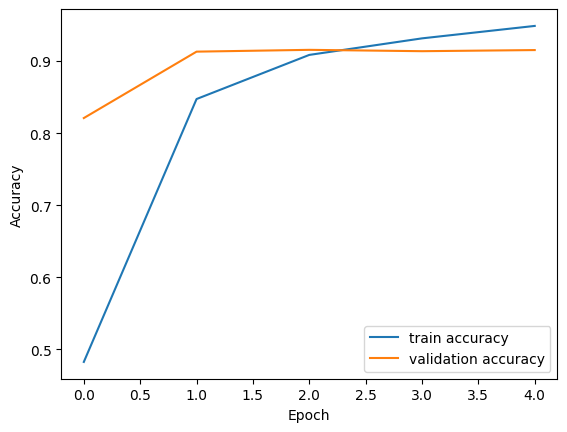

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

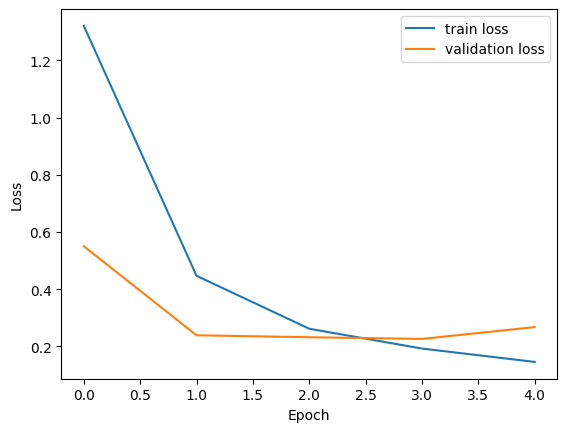

In [19]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [21]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9195
F1 macro: 0.8771613490970857
              precision    recall  f1-score   support

       anger       0.91      0.95      0.93       275
        fear       0.90      0.85      0.88       224
         joy       0.94      0.94      0.94       695
        love       0.78      0.85      0.82       159
     sadness       0.96      0.95      0.96       581
    surprise       0.74      0.76      0.75        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



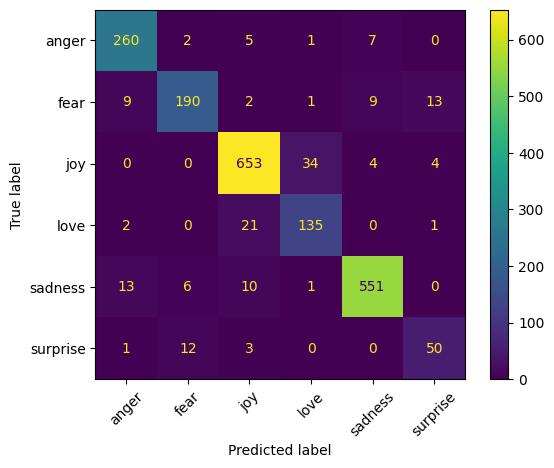

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(xticks_rotation=45)
plt.show()

In [23]:
for i in range(20):
    true_label = le.inverse_transform([y_test[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]

    if true_label != pred_label:
        print("TEXT:", X_test.iloc[i])
        print("TRUE:", true_label)
        print("PRED:", pred_label)
        print("-" * 50)

TEXT: i don t feel particularly agitated
TRUE: fear
PRED: anger
--------------------------------------------------
TEXT: i pay attention it deepens into a feeling of being invaded and helpless
TRUE: fear
PRED: sadness
--------------------------------------------------
TEXT: i feel like my only role now would be to tear your sails with my pessimism and discontent
TRUE: sadness
PRED: joy
--------------------------------------------------
